# Enhanced RL Agent for Optimal Epidemic Control

This notebook implements an enhanced Reinforcement Learning agent with:
- **Double DQN**: Improves Q-value estimation stability
- **Dueling DQN**: Separates value and advantage streams for better learning
- **Prioritized Experience Replay**: Focuses learning on surprising experiences
- **Enhanced Reward Function**: Includes intervention stability penalty

## Model Improvements Implemented:
1. **Upgraded Learning Algorithm**: Transition from standard DQN to Double DQN
2. **Refined Reward Signal**: Added penalty for frequent intervention changes
3. **Improved Learning Process**: Implemented Prioritized Experience Replay

In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.8 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv
import joblib
import numpy as np
import collections
import random
import matplotlib.pyplot as plt
import torch.optim as optim
import heapq
from typing import List, Tuple, Optional

In [5]:
# 1. First, the model's class definition must be present in this notebook too.
class SpatioTemporalGNN_v2(nn.Module):
    def __init__(self, num_nodes, lookback_window, forecast_horizon):
        super(SpatioTemporalGNN_v2, self).__init__()
        self.num_nodes = num_nodes
        self.lookback_window = lookback_window
        self.forecast_horizon = forecast_horizon
        self.gcn = GCNConv(1, 64)
        self.dropout1 = nn.Dropout(0.3)
        self.lstm = nn.LSTM(input_size=64 * num_nodes, hidden_size=256, num_layers=2, batch_first=True)
        self.dropout2 = nn.Dropout(0.3)
        self.linear = nn.Linear(256, num_nodes * forecast_horizon)

    def forward(self, x, edge_index):
        gcn_outputs = []
        for t in range(self.lookback_window):
            snapshot = x[:, t, :].unsqueeze(-1)
            batch_gcn_out = [torch.relu(self.gcn(snapshot[i], edge_index)) for i in range(x.size(0))]
            gcn_out_batch_tensor = torch.stack(batch_gcn_out)
            gcn_outputs.append(gcn_out_batch_tensor)

        gcn_sequence = torch.stack(gcn_outputs, dim=1)
        gcn_sequence = self.dropout1(gcn_sequence)
        lstm_input = gcn_sequence.view(x.size(0), self.lookback_window, -1)
        lstm_out, _ = self.lstm(lstm_input)
        last_time_step_out = lstm_out[:, -1, :]
        last_time_step_out = self.dropout2(last_time_step_out)
        output = self.linear(last_time_step_out)
        output = output.view(-1, self.forecast_horizon, self.num_nodes)
        return output

# 2. Load the saved parameters and artifacts
other_params = torch.load('other_params.pth')
num_states = other_params['num_states']
lookback_window = other_params['lookback_window']
forecast_horizon = other_params['forecast_horizon']
edge_index = other_params['edge_index']
X_test_tensor = other_params['X_test_tensor']
state_to_idx = other_params['state_to_idx']
scaler = joblib.load('min_max_scaler')

# 3. Instantiate the model and load the trained weights
model_v2 = SpatioTemporalGNN_v2(num_states, lookback_window, forecast_horizon)
model_v2.load_state_dict(torch.load('gnn_lstm_model_v2.pth'))
model_v2.eval() # Set it to evaluation mode, as we won't be training it further here

print("Enhanced GNN-LSTM model loaded successfully!")

Enhanced GNN-LSTM model loaded successfully!


Prioritized Replay Buffer

In [6]:
class PrioritizedReplayBuffer:
    """Prioritized Experience Replay Buffer for more efficient learning."""

    def __init__(self, capacity: int, alpha: float = 0.6, beta: float = 0.4, beta_increment: float = 0.001):
        self.capacity = capacity
        self.alpha = alpha  # Priority exponent
        self.beta = beta    # Importance sampling exponent
        self.beta_increment = beta_increment
        self.buffer = []
        self.priorities = []
        self.position = 0
        self.max_priority = 1.0

    def push(self, state, action, reward, next_state, done):
        """Add experience to buffer with maximum priority."""
        experience = (state, action, reward, next_state, done)

        if len(self.buffer) < self.capacity:
            self.buffer.append(experience)
            self.priorities.append(self.max_priority)
        else:
            self.buffer[self.position] = experience
            self.priorities[self.position] = self.max_priority

        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size: int) -> Tuple[List, List[int], torch.Tensor]:
        """Sample experiences with priority-based sampling."""
        if len(self.buffer) < batch_size:
            return self.buffer, list(range(len(self.buffer))), torch.ones(len(self.buffer))

        # Calculate sampling probabilities based on priorities
        priorities = np.array(self.priorities[:len(self.buffer)])
        probabilities = priorities ** self.alpha
        probabilities /= probabilities.sum()

        # Sample indices
        indices = np.random.choice(len(self.buffer), batch_size, p=probabilities)

        # Calculate importance sampling weights
        weights = (len(self.buffer) * probabilities[indices]) ** (-self.beta)
        weights /= weights.max()
        weights = torch.FloatTensor(weights)

        # Update beta
        self.beta = min(1.0, self.beta + self.beta_increment)

        return [self.buffer[idx] for idx in indices], indices, weights

    def update_priorities(self, indices: List[int], priorities: List[float]):
        """Update priorities based on TD errors."""
        for idx, priority in zip(indices, priorities):
            self.priorities[idx] = priority
            self.max_priority = max(self.max_priority, priority)

    def __len__(self):
        return len(self.buffer)

Dueling Q-Network

In [7]:
class DuelingQNetwork(nn.Module):
    """Dueling DQN architecture with separate value and advantage streams."""

    def __init__(self, input_shape, num_actions):
        super(DuelingQNetwork, self).__init__()
        input_size = np.prod(input_shape)

        # Shared feature layers
        self.feature_layer = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Value stream
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # Advantage stream
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_actions)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input
        features = self.feature_layer(x)

        value = self.value_stream(features)
        advantage = self.advantage_stream(features)

        # Combine value and advantage streams
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))
        return q_values

In [8]:
class DoubleDuelingDQNAgent:
    """Enhanced DQN agent with Double DQN, Dueling architecture, and Prioritized Experience Replay."""

    def __init__(self, state_shape, num_actions, buffer_size=10000, gamma=0.99, lr=1e-4,
                 target_update_freq=100, double_dqn=True):
        self.num_actions = num_actions
        self.gamma = gamma
        self.double_dqn = double_dqn
        self.target_update_freq = target_update_freq
        self.update_count = 0

        # Networks
        self.q_network = DuelingQNetwork(state_shape, num_actions)
        self.target_network = DuelingQNetwork(state_shape, num_actions)
        self.target_network.load_state_dict(self.q_network.state_dict())

        # Optimizer
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr, weight_decay=1e-5)

        # Prioritized replay buffer
        self.replay_buffer = PrioritizedReplayBuffer(buffer_size)

        # Action history for stability penalty
        self.action_history = collections.deque(maxlen=10)

    def select_action(self, state, epsilon):
        """Epsilon-greedy action selection with action history tracking."""
        if random.random() < epsilon:
            action = random.randint(0, self.num_actions - 1)
        else:
            with torch.no_grad():
                q_values = self.q_network(state)
                action = q_values.argmax().item()

        self.action_history.append(action)
        return action

    def store_experience(self, state, action, reward, next_state, done):
        """Store experience in prioritized replay buffer."""
        self.replay_buffer.push(state, action, reward, next_state, done)

    def learn(self, batch_size):
        """Learn from experiences using Double DQN and prioritized replay."""
        if len(self.replay_buffer) < batch_size:
            return

        # Sample experiences with priorities
        experiences, indices, weights = self.replay_buffer.sample(batch_size)
        states, actions, rewards, next_states, dones = zip(*experiences)

        # Convert to tensors
        states = torch.cat(states).float()
        actions = torch.tensor(actions).unsqueeze(1).long()
        rewards = torch.tensor(rewards).unsqueeze(1).float()
        next_states = torch.cat(next_states).float()
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).float()
        weights = weights.unsqueeze(1)

        # Current Q values
        current_q_values = self.q_network(states).gather(1, actions)

        # Next Q values using Double DQN
        if self.double_dqn:
            # Use main network to select actions
            next_actions = self.q_network(next_states).argmax(1).unsqueeze(1)
            # Use target network to evaluate actions
            next_q_values = self.target_network(next_states).gather(1, next_actions)
        else:
            # Standard DQN
            next_q_values = self.target_network(next_states).max(1)[0].unsqueeze(1)

        # TD target
        target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

        # TD error for priority update
        td_errors = torch.abs(target_q_values - current_q_values).detach().numpy().flatten()

        # Weighted loss
        loss = (weights * nn.MSELoss(reduction='none')(current_q_values, target_q_values)).mean()

        # Update network
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=1.0)  # Gradient clipping
        self.optimizer.step()

        # Update priorities
        self.replay_buffer.update_priorities(indices, td_errors + 1e-6)  # Add small constant to avoid zero priority

        # Update target network
        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.update_target_network()

    def update_target_network(self):
        """Soft update of target network."""
        tau = 0.01  # Soft update parameter
        for target_param, local_param in zip(self.target_network.parameters(), self.q_network.parameters()):
            target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)

Enhanced Epidemic Environment

In [9]:
class EnhancedEpidemicEnv:
    def __init__(self, predictive_model, initial_state, scaler, edge_index, num_states, forecast_horizon):
        self.model = predictive_model
        self.initial_state = initial_state
        self.scaler = scaler
        self.edge_index = edge_index
        self.num_states = num_states
        self.forecast_horizon = forecast_horizon

        # State Space (S): The state is the sequence of recent case data
        self.state = initial_state.clone().detach()

        # Action Space (A): Discrete set of NPIs
        # Action 0: No intervention
        # Action 1: Moderate intervention (e.g., mask advisory)
        # Action 2: Strict intervention (e.g., lockdown)
        self.action_space_n = 3

        # Pre-defined socioeconomic costs for each action
        self.action_costs = {0: 0.0, 1: 0.4, 2: 1.0}

        # Enhanced weights for the reward function
        self.w_infection = 0.6
        self.w_socioeconomic = 0.3
        self.w_stability = 0.1  # New weight for stability penalty

        # Action history for stability tracking
        self.action_history = collections.deque(maxlen=10)

    def reset(self):
        # Reset the environment to the initial state for a new episode
        self.state = self.initial_state.clone().detach()
        self.action_history.clear()
        return self.state

    def step(self, action):
        # Track action for stability penalty
        self.action_history.append(action)

        # --- Transition Dynamics (P) ---
        # Use the GNN-LSTM to predict the next state
        self.model.eval()
        with torch.no_grad():
            # The model predicts the next H days. We take the first day as the next state.
            predicted_scaled_forecast = self.model(self.state, self.edge_index)
            next_state_scaled_partial = predicted_scaled_forecast[:, 0, :].unsqueeze(1)

        # Update our state: drop the oldest day and append the new predicted day
        new_state_scaled = torch.cat((self.state[:, 1:, :], next_state_scaled_partial), dim=1)

        # --- Enhanced Reward Function (R) ---
        # Calculate new infections
        last_day_cases_scaled = self.state[:, -1, :]
        new_day_cases_scaled = next_state_scaled_partial.squeeze(1)

        # Inverse transform to get real numbers
        last_day_cases_log = self.scaler.inverse_transform(last_day_cases_scaled)
        new_day_cases_log = self.scaler.inverse_transform(new_day_cases_scaled)

        last_day_cases_actual = np.expm1(last_day_cases_log)
        new_day_cases_actual = np.expm1(new_day_cases_log)

        # Total new infections across all states
        delta_infections = np.sum(new_day_cases_actual - last_day_cases_actual)
        normalized_delta_infections = delta_infections / 1_000_000

        # Intervention cost
        intervention_cost = self.action_costs[action]

        # Stability penalty for frequent action changes
        stability_penalty = self._calculate_stability_penalty()

        # Enhanced reward with stability consideration
        reward = - (self.w_infection * normalized_delta_infections +
                      self.w_socioeconomic * intervention_cost +
                      self.w_stability * stability_penalty)

        self.state = new_state_scaled
        done = False

        return self.state, reward, done

    def _calculate_stability_penalty(self):
        """Calculate penalty for frequent intervention changes."""
        if len(self.action_history) < 2:
            return 0.0

        # Count recent action changes
        recent_actions = list(self.action_history)[-5:]  # Last 5 actions
        action_changes = sum(1 for i in range(1, len(recent_actions))
                             if recent_actions[i] != recent_actions[i-1])

        # Penalty increases with more frequent changes
        stability_penalty = 0.2 * action_changes
        return stability_penalty

In [10]:
# --- Initialize Enhanced Environment and Agent ---
# Let's take the first sequence from our test set as the starting point
initial_env_state = X_test_tensor[0].unsqueeze(0)

env = EnhancedEpidemicEnv(model_v2, initial_env_state, scaler, edge_index, num_states, forecast_horizon)
agent = DoubleDuelingDQNAgent(state_shape=initial_env_state.shape[1:], num_actions=env.action_space_n)

print("Enhanced RL Environment and Agent initialized successfully!")

Enhanced RL Environment and Agent initialized successfully!


In [11]:
# --- Training Parameters ---
num_episodes = 200
max_steps_per_episode = 180
batch_size = 32
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 0.995

epsilon = epsilon_start
episode_rewards = []
episode_interventions = []
episode_stability_scores = []

print("Starting Enhanced RL agent training...")
for episode in range(num_episodes):
    state = env.reset()
    total_reward = 0
    intervention_sequence = []

    for step in range(max_steps_per_episode):
        # Agent selects an action based on the current state
        action = agent.select_action(state, epsilon)

        # Environment transitions to the next state and returns a reward
        next_state, reward, done = env.step(action)

        # Agent stores this experience and learns from a batch of past experiences
        agent.store_experience(state, action, reward, next_state, done)
        agent.learn(batch_size)

        state = next_state
        total_reward += reward
        intervention_sequence.append(action)

    # Calculate stability score for this episode
    changes = sum(1 for i in range(1, len(intervention_sequence))
                  if intervention_sequence[i] != intervention_sequence[i-1])
    stability_score = 1.0 - (changes / len(intervention_sequence))

    episode_rewards.append(total_reward)
    episode_interventions.append(intervention_sequence)
    episode_stability_scores.append(stability_score)

    epsilon = max(epsilon_end, epsilon * epsilon_decay)

    if (episode + 1) % 20 == 0:
        print(f"Episode {episode+1}/{num_episodes}, Total Reward: {total_reward:.2f}, "
              f"Epsilon: {epsilon:.3f}, Stability: {stability_score:.3f}")

print("Finished Enhanced RL Training!")

Starting Enhanced RL agent training...
Episode 20/200, Total Reward: -30.61, Epsilon: 0.905, Stability: 0.372
Episode 40/200, Total Reward: -28.95, Epsilon: 0.818, Stability: 0.356
Episode 60/200, Total Reward: -28.85, Epsilon: 0.740, Stability: 0.350
Episode 80/200, Total Reward: -26.07, Epsilon: 0.670, Stability: 0.406
Episode 100/200, Total Reward: -20.89, Epsilon: 0.606, Stability: 0.450
Episode 120/200, Total Reward: -17.37, Epsilon: 0.548, Stability: 0.517
Episode 140/200, Total Reward: -14.77, Epsilon: 0.496, Stability: 0.567
Episode 160/200, Total Reward: -19.03, Epsilon: 0.448, Stability: 0.500
Episode 180/200, Total Reward: -15.69, Epsilon: 0.406, Stability: 0.578
Episode 200/200, Total Reward: -14.05, Epsilon: 0.367, Stability: 0.611
Finished Enhanced RL Training!


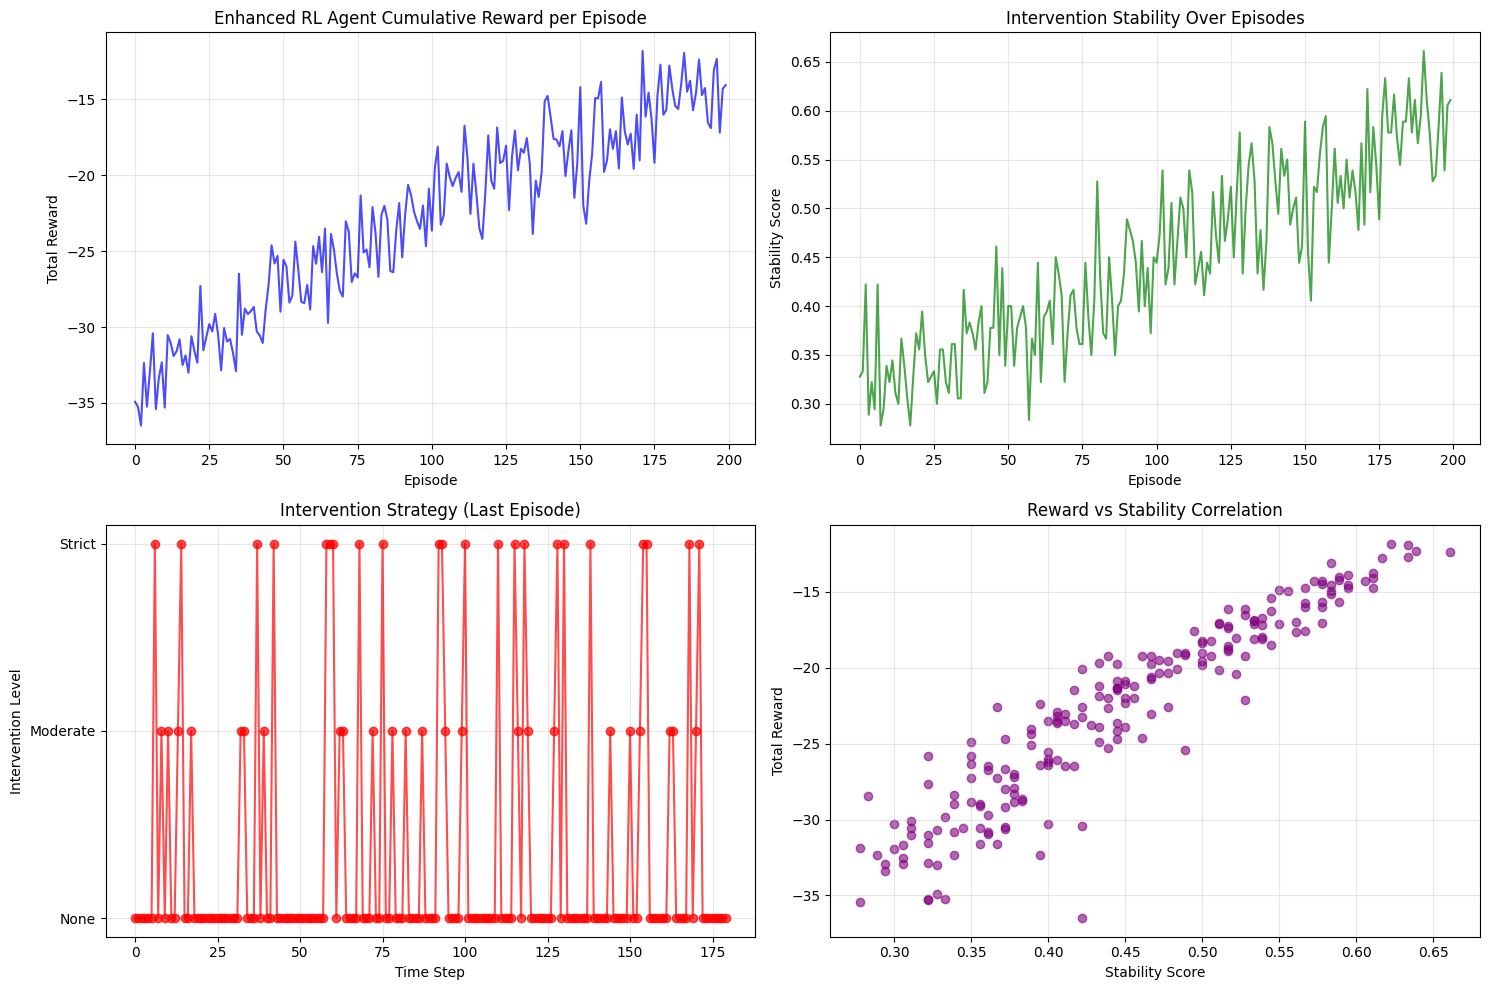

In [12]:
# --- Plot Enhanced RL Training Results ---
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot rewards
ax1.plot(episode_rewards, color='blue', alpha=0.7)
ax1.set_title('Enhanced RL Agent Cumulative Reward per Episode')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.grid(True, alpha=0.3)

# Plot stability scores
ax2.plot(episode_stability_scores, color='green', alpha=0.7)
ax2.set_title('Intervention Stability Over Episodes')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Stability Score')
ax2.grid(True, alpha=0.3)

# Plot intervention patterns for last episode
last_interventions = episode_interventions[-1]
ax3.plot(last_interventions, marker='o', color='red', alpha=0.7)
ax3.set_title('Intervention Strategy (Last Episode)')
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Intervention Level')
ax3.set_yticks([0, 1, 2])
ax3.set_yticklabels(['None', 'Moderate', 'Strict'])
ax3.grid(True, alpha=0.3)

# Plot reward vs stability correlation
ax4.scatter(episode_stability_scores, episode_rewards, alpha=0.6, color='purple')
ax4.set_title('Reward vs Stability Correlation')
ax4.set_xlabel('Stability Score')
ax4.set_ylabel('Total Reward')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# --- Save Enhanced Model ---
from google.colab import drive
import os
import joblib

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Epidemic_Forecasting_Project/'
os.makedirs(save_path, exist_ok=True)

torch.save(model_v2.state_dict(), os.path.join(save_path, 'gnn_lstm_model.pth'))
print(f"Predictive model saved to: {os.path.join(save_path, 'gnn_lstm_model.pth')}")

torch.save(agent.q_network.state_dict(), os.path.join(save_path, 'enhanced_rl_agent_q_network.pth'))
print(f"Enhanced RL agent's Q-Network saved to: {os.path.join(save_path, 'enhanced_rl_agent_q_network.pth')}")

joblib.dump(scaler, os.path.join(save_path, 'data_scaler.gz'))
print(f"Data scaler saved to: {os.path.join(save_path, 'data_scaler.gz')}")

project_params = {
    'num_states': num_states,
    'lookback_window': lookback_window,
    'forecast_horizon': forecast_horizon,
    'edge_index': edge_index,
    'state_to_idx': state_to_idx
}
torch.save(project_params, os.path.join(save_path, 'project_params.pth'))
print(f"Project parameters saved to: {os.path.join(save_path, 'project_params.pth')}")

# Save training metrics
training_metrics = {
    'episode_rewards': episode_rewards,
    'episode_stability_scores': episode_stability_scores,
    'episode_interventions': episode_interventions,
}
torch.save(training_metrics, os.path.join(save_path, 'enhanced_rl_training_metrics.pth'))
print(f"Enhanced RL training metrics saved to: {os.path.join(save_path, 'enhanced_rl_training_metrics.pth')}")

print("\nAll files have been successfully exported to your Google Drive. ✅")

print("\n=== Summary of Enhancements ===")
print("1. Double DQN: Reduces overestimation bias in Q-values")
print("2. Dueling DQN: Separates value and advantage streams")
print("3. Prioritized Experience Replay: Focuses on surprising experiences")
print("4. Enhanced Reward Function: Includes stability penalty")
print("5. Additional improvements: Gradient clipping, soft updates, regularization")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Predictive model saved to: /content/drive/MyDrive/Epidemic_Forecasting_Project/gnn_lstm_model.pth
Enhanced RL agent's Q-Network saved to: /content/drive/MyDrive/Epidemic_Forecasting_Project/enhanced_rl_agent_q_network.pth
Data scaler saved to: /content/drive/MyDrive/Epidemic_Forecasting_Project/data_scaler.gz
Project parameters saved to: /content/drive/MyDrive/Epidemic_Forecasting_Project/project_params.pth
Enhanced RL training metrics saved to: /content/drive/MyDrive/Epidemic_Forecasting_Project/enhanced_rl_training_metrics.pth

All files have been successfully exported to your Google Drive. ✅

=== Summary of Enhancements ===
1. Double DQN: Reduces overestimation bias in Q-values
2. Dueling DQN: Separates value and advantage streams
3. Prioritized Experience Replay: Focuses on surprising experiences
4. Enhanced Reward Function: Includes stability penalty
5. 